# Objective: #
Create a pipeline to go from the MSC dataset to a clean ROI timeseries.

In [2]:
# !fmriprep-docker --fs-license-file /home/tahia/Documents/MSC/scripts/license.txt /home/tahia/Documents/MSC/data/ds000224 /home/tahia/Documents/MSC/data/fmri_output/derivatives participant -w /home/tahia/Documents/MSC/data/fmri_output/scratch --task-id memoryscenes --skip-bids-validation

Turning raw brain data into usable format is somewhat of a process. Initially, you start with dicom files and a bunch of 'environmental variables' that must then be used to create nifti files. Once that's done, you have to motion correct, register, and create the brain mask, among other steps. Luckily, fMRIPrep does all of this for you. An example of a command one might use with fMRIPrep is given above. 

In [3]:
import os
import sys
from pathlib import Path
import logging
import warnings
import gc
from datetime import datetime
import multiprocessing as mp
import concurrent.futures
# from tqdm import tqdm
import json
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn as nil
from nilearn.plotting import plot_epi
from nilearn.glm.first_level import make_first_level_design_matrix
from scipy import stats

### Saving and Tracking ###

In [4]:
# Set up logging and deal with any warnings.
today = datetime.now().date().strftime("%Y-%m-%d")

logging.basicConfig(
    level=logging.INFO, 
    format="%(asctime)s - %(levelname)s - %(message)s", 
    datefmt="%Y-%m-%d %H:%M:%S", 
    handlers=[
        logging.FileHandler(f"./logs/msc_data_generation_{today}.log", mode='w'), 
        logging.StreamHandler(sys.stdout)
    ]
)

warnings.filterwarnings('ignore')

In [34]:
# A dictionary of all the stuff we'd otherwise have to keep writing out; 
# this way, we only ever have to change things up here.
config = {
    'data_dir': "../data/fmriprep_output/derivatives",
    'raw_dir': "../data/ds000224",
    'roi_mask_suffix': "Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'data_output_dir': 'datasets', 
    'scan_dim_3d': (0,0,0),
    'roi_label': 'roi-rnd_wb',
    'roi_coord_MNI': (-15, -1, -3), #np.random.randint(low=-24,high=24,size=3), #(24, -2, -20),
    'roi_radius': 10,
    'encoding_label': 'encoding-stimxhrf',
    'csv_suffix': 'desc-vox_w_stim_hrf.csv',
    'parquet_suffix': 'desc-vox_w_stim_hrf.parquet',
    'date_suffix': today,
    'nilearn_defaults': {
         'standardize': False, #'psc',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2
        },
    'hrf_model': 'spm'
}

In [6]:
def json_compatibility_encoder(obj):
    """
    A helper function to convert numpy types to python floats  
    and ints to keep the json library from getting mad about 
    type unserializability. If we can't convert to the right 
    numeric type, we go for string type.

    Parameters
    ----------
    obj : numeric, string, or other data types
        Meta data from the global config variable that need
        to be converted into native python types.

    Returns
    -------
    float, int, string
        Converts object into the correct type for the json file.
    """
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    return str(obj)

In [7]:
def save_dataset_with_metadata(df, config, today_date, voxel_dims, applied_nil_params):
    """
    Saves the dataframe and its metadata to a unique, programmatically named directory
    to prevent dataset over-writing and to ensure dataset generation traceability.

    Parameters
    ----------
    df : pandas.DataFrame
        Fully processed and concatenated pandas dataframe containing timeseries for voxels in ROI.
    config : dict
        Dictionary containing all parameters for dataset generation.
    today_date : str
        A string representing the current date (e.g., "YYYY-MM-DD") used for naming.
    voxel_dims : tuple of float
        A tuple containing the x, y, and z dimensions of the functional scan voxels.
    applied_nil_params : dict
        A dictionary containing the precise nilearn parameters applied during the time series extraction.

    Returns
    -------
    None
        The function saves the dataframe as a Parquet file and the metadata as a JSON 
        file directly to the disk.
    """
    gen_id = f"dataset_{config['task_label']}_{config['roi_label']}"
    
    gen_dir = os.path.join(config['data_output_dir'], gen_id)
    os.makedirs(gen_dir, exist_ok=True)

    coord_array =  "_".join(map(str, config['roi_coord_MNI']))
    parquet_path = os.path.join(gen_dir, "_".join([gen_id, coord_array, f"date-{today_date}", config['parquet_suffix']]))
    json_path = os.path.join(gen_dir, "_".join([gen_id, coord_array, f"date-{today_date}", "metadata.json"]))
    
    metadata = {
        "generation_id": gen_id,
        "generation_date": today_date,
        "base_configuration": config,
        "updated_config_params": {
            "voxel_dimensions": voxel_dims,
            "applied_nil_params": applied_nil_params
        },
        "data_summary": {
            "total_rows": len(df),
            "subjects": df['subj'].unique().tolist() if 'subj' in df.columns else "N/A",
            "sessions": df['sess'].unique().tolist() if 'sess' in df.columns else "N/A",
            "columns": df.columns.tolist()
        }
    }
    
    df.columns = df.columns.astype(str)
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    
    with open(json_path, 'w') as f:
        json.dump(metadata, f, indent=4, default=json_compatibility_encoder)
        
    logging.info("Successfully saved unique dataset and metadata to: %s", parquet_path)

### Utilities ###

In [8]:
def skull_strip(path_to_brain, path_to_mask):
    """
    Applies the brain mask from the specified path to the preprocessed brain from the
    specified path. 
    
    Parameters
    ----------
    path_to_brain : str
        File path to the 4D NIfTI image containing the brain and skull labeled 
        as the preproc_brain by fMRIPrep.
    path_to_mask : str
        File path to the binary 3D NIfTI brain mask also generated by fMRIPrep.

    Returns
    -------
    nibabel.nifti1.Nifti1Image or None
        A new 4D NIfTI image object containing the skull-stripped brain data,
        preserving the original affine and header if possible. If skull-stripping
        isn't possible, the original 4D NIfTI image is loaded and returned. 
        If the 4D NIfTI image cannot be found or opened, None is returned.

    Raises
    ------
    FileNotFoundError, nib.filebasedimages.ImageFileError
        If either the file specified by the given path is missing or if the file 
        cannot be read by nibabel for whatever reason.
    ValueError
        If either the values within a nibabel-loaded NIfTI image are incorrect or 
        if the shape of the image is incorrect.
    Exception
        If other unexpected errors arise.
    """
    
    logging.info("Initiating skull-stripping for pre-processed brain %s.", os.path.basename(path_to_brain))

    # Open brain file
    try:
        brain_img = nib.load(path_to_brain)
    except (FileNotFoundError, nib.filebasedimages.ImageFileError):
        # In the event of missing brain, we log the issue and return
        # None so that the main script is aware this is a big nada
        logging.warning("Brain image missing or invalid at location: %s. \nSkipping run...", os.path.abspath(path_to_brain))
        return None
    except Exception as e:
        logging.error("Unexpected failure %s when loading nifti image file %s.", e, os.path.abspath(path_to_brain), exc_info=True)
        raise
        
    # Open mask file; return original brain image on failure
    try:
        mask_img = nib.load(path_to_mask)
    except (FileNotFoundError, nib.filebasedimages.ImageFileError):
        # In the event of missing mask, we log the issue and return
        # the original brain image we loaded so that the script can
        # continue even if skull-stripping fails. As the brains are
        # all in the same space, this may not end up being an issue.
        logging.warning("Mask image missing or invalid at location: %s. \nSkipping skull-stripping...", os.path.abspath(path_to_mask))
        return brain_img
    except Exception as e:
        logging.error("Unexpected failure %s when opening file %s.", e, os.path.abspath(path_to_mask), exc_info=True)
        return brain_img

    # Check if mask image if binary
    mask_vals = mask_img.get_fdata()
    binary_test = np.all(np.isclose(mask_vals, 0, atol=1e-5) | np.isclose(mask_vals, 1, atol=1e-5))
    if not binary_test:
        # If both brain image and mask image are proper nifti files that opened without problems,
        # if the mask is not in face binary, we are having a HUGE problem somewhere: is everything named
        # correctly? did fMRIPrep fail somehow? did the user put in the wrong path? is the brain image 
        # file even the correct one?! This is thus an epic error.
        logging.critical("Type Mismatch: Non-binary nifti image file found in location: %s when looking for brain mask!", os.path.abspath(path_to_mask))
        raise ValueError(f"Fatal Error: Binary nifti image file expected at location {os.path.abspath(path_to_mask)}; got non-binary nifti image file instead!")

    # Actually stripping the skull
    try:
        skull_stripped_img = brain_img.get_fdata() * mask_vals[..., None]
    except ValueError:
        logging.critical("Shape Mismatch: The brain %s (shape: %s) and the mask %s (shape: %s) are in different spaces.", os.path.basename(path_to_brain), brain_img.shape, os.path.basename(path_to_mask), mask_img.shape, exc_info=True)
        raise
    except Exception as e:
        # This should not happen.  At this point, the only explanation is something is wrong with the brain image somehow. 
        logging.error("Unexpected failure when applying mask to brain image %s: %s. \nReturning original brain image...", os.path.basename(path_to_brain), e, exc_info=True)
        return brain_img

    # There should be no problem here
    preproc_bold = nib.Nifti1Image(skull_stripped_img, brain_img.affine, brain_img.header)
    logging.info("Successfully skull-stripped %s!", os.path.basename(path_to_brain))
    return preproc_bold

In [9]:
def ts_mat_to_df(ts_mat, t_r=2.2):
    """
    Takes in a number of scans x number of voxels array and returns a dataframe.

    Parameters
    ----------
    ts_mat: numpy.ndarray
        An n_scans x n_voxels array of a 4D brain wherein n_voxels refers to the flattened 
        brain and n_scans refers to each time the brain was scanned.
    t_r: float
        The time interval between scans in seconds.

    Returns
    -------
    pandas.DataFrame
        A dataframe of the same shape as the input ts_mat with columns and index labeled.

    TODO: remove once no longer in use; i.e., nil implements set_output().
    """
    
    idx = np.round(np.arange(ts_mat.shape[0])*t_r, 2)
    roidf = pd.DataFrame(data=ts_mat, index=idx, columns=["v"+str(i) for i in range(ts_mat.shape[1])])
    
    return roidf

In [33]:
def get_run_paths(sub_id, ses_id, config):
    """
    Generates all required file paths for a given subject and session run.

    Parameters
    ----------
    sub_id: int
        The number portion of the subject identifier (e.g., sub-MSC05 -> 5).
    ses_id: int
        The number portion of the session identifier for the subject above
        (e.g., ses-func09 -> 9).
    config: dict
        The dictionary outlining the basic parameters of this dataset creation.

    Returns
    -------
    dict
        A dictionary mapping path keys (e.g., 'brain', 'mask', 'confounds', 'events', 
        'skull_stripped', 'output_file') to their absolute string path locations.
    """
    # Automatically zero-pad integers to 2 digits because that's how MSC rolls.
    sub_str = f"{config['subj_prefix']}{sub_id:02d}"
    ses_str = f"{config['sess_prefix']}{ses_id:02d}"
    
    # Define base directories using pathlib.
    data_dir = Path(config['data_dir']) / sub_str / ses_str / 'func'
    raw_dir = Path(config['raw_dir']) / sub_str / ses_str / 'func'
    out_dir = Path(config['data_output_dir'])
    
    # Create dictionary of paths for each object.
    coord_array = "_".join(map(str, config['roi_coord_MNI']))
    paths = {
        'brain': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_{config['bold_suffix']}",
        'mask': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_{config['mask_suffix']}",
        'confounds': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['confounds_suffix']}",
        'events': raw_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['events_suffix']}",
        # 'sphere': out_dir / f"{sub_str}_{ses_str}_{config['roi_label']}_{config['roi_coord_MNI']}_{config['roi_mask_suffix']}",
        'skull_stripped': data_dir / f"{sub_str}_{ses_str}_{config['task_label']}_{config['space_label']}_desc-skull_stripped_preproc_bold.nii.gz",
        'output_file': data_dir.parent / 'datasets' / f"{sub_str}_{ses_str}_{config['task_label']}_{config['roi_label']}_{coord_array}_{config['encoding_label']}_{config['date_suffix']}_{config['parquet_suffix']}"
    }
    
    # Convert pathlib Path objects back to strings for use in other functions.
    return {k: str(v) for k, v in paths.items()}

In [22]:
def process_session(sid, ssid, paths, config, p_ROI_sphere_mask):
    """
    Executes the fMRI processing pipeline for a single session.

    Parameters
    ----------
    sid : int
        The integer identifier for the current subject.
    ssid : int
        The integer identifier for the current functional session.
    paths : dict
        A dictionary containing the generated file paths for the current run, 
        produced by the get_run_paths function.
    config : dict
        The global configuration dictionary.
    p_ROI_sphere_mask : str
        The file path to the globally generated 3D NIfTI ROI sphere mask.

    Returns
    -------
    tuple
        A tuple containing two items for metadata logging:
        - voxel_dims (tuple): The (x, y, z) spatial dimensions of the BOLD image.
        - current_run_params (dict): The final dictionary of Nilearn parameters applied.
        Returns (None, None) if the skull-stripping fails or the BOLD image cannot be opened.
    """
    skull_stripped_save_path = paths['skull_stripped']
    
    # Load or generate skull-stripped brain
    if os.path.isfile(skull_stripped_save_path):
        logging.info("Subject %s, session %s is already skull stripped! Loading %s", sid, ssid, skull_stripped_save_path)
        bold_img = nib.load(skull_stripped_save_path)
    else:
        logging.info("Subject %s, session %s skull-stripped 4D scan not found. Stripping skull...", sid, ssid)
        bold_img = skull_strip(paths['brain'], paths['mask'])
        if bold_img is not None:
            nib.save(bold_img, skull_stripped_save_path)
            
    if bold_img is None:
        return None, None # Safety exit if skull-stripping fails

    # Extract voxel dimensions
    vx, vy, vz, tr_val = bold_img.header.get_zooms()
    voxel_dims = (vx, vy, vz)
        
    # Define run-specific nilearn parameters
    current_run_params = config['nilearn_defaults'] | {'t_r': tr_val}
        
    # Extract Timeseries as a pandas.DataFrame
    logging.info("Extracting timeseries from subject %s, session %s.", sid, ssid)
    fef_ts, fef_kern = brain_to_tsdf(bold_img, p_ROI_sphere_mask, paths['confounds'], nil_defaults=current_run_params)
    fdf = ts_mat_to_df(fef_ts, t_r=tr_val)
    
    # Apply Design Matrix for task defined in config
    logging.info("Creating design matrix for subject %s, session %s.", sid, ssid)
    dmdf = design_matrix_creation(paths['events'], fdf.index)
    fdf['indoor'] = dmdf['indoor']
    fdf['outdoor'] = dmdf['outdoor']

    # Add identifiers
    fdf['subj'] = sid
    fdf['sess'] = ssid
    fdf.columns = fdf.columns.astype(str)
    
    # Save output
    logging.info("Saving parquet file %s!", paths['output_file'])
    os.makedirs(os.path.dirname(paths['output_file']), exist_ok=True)
    fdf.to_parquet(paths['output_file'], engine='pyarrow')
    
    # Eat the trash
    del bold_img
    del fef_ts
    del fdf
    gc.collect()
    
    # Return the dynamic data for the metadata file
    return voxel_dims, current_run_params, fef_kern

### Data Extraction ###

Regions of interest (ROI) are generally selected via two methods: 1) an anatomical mask of the ROI, and 2) a spherical mask based upon activity. They each have their drawbacks, which I will not discuss here, as well as their benefits. However, neither quite work for me. For one thing, an anatomical mask will always have the caveat that unless an anatomist traced out the outline for the ROI on individual, pre-warped brains, one isn't guaranteed to get a clean signal (signal will be dropped or gained via unwanted voxels). Even if one did trace out the exact anatomical mask, in much of the neocortex, the functional information may not necessarily be captured in that mask. 

Seed-based analysis, on the other hand, is based on functional information rather than the anatomic particulars. Here, one uses a spherical mask centered on some coordinate to then use the information for further analysis. Although a spherical mask, given the fact that brain regions are not spherical, sounds fairly coarse in comparison to the anatomical masks, it's a much easier to use and arguably equivalent in its resolution due to the inherent issues with using anatomical maps and the various arguments that still persist regarding cortical parcellation.

Given all of this, I've chosen to use spherical ROIs large enough to cover the whole of my anatomical ROI. In effect, we'll gather all the signal that might have the info we want and discard whatever doesn't.

In [12]:
# Sphere mask creation
# Turns out this is more annoying than expected, so let's just do math. 

def ROI_sphere(path_to_brain, MNI_coord, scan_dim, radius):
    """
    Returns an ROI sphere mask for a 3d or 4d volume given the center and radius.

    Parameters
    ----------
    path_to_brain : str
        File path to the 3D or 4D NIfTI image containing the brain image.
    MNI_coord : tuple
        The x, y, z coordinates for the center of the sphere in MNI space.
    scan_dim: tuple or list of floats
        The length of each voxel dimension as a set of X, Y, and Z floats in mm.
    radius : float
        The radius of the sphere in millimeters.

    Returns
    -------
    nibabel.nifti1.Nifti1Image
        A mask ready to be used with the input image.

    Raises
    ------
    FileNotFoundError, nib.filebasedimages.ImageFileError
        If either the file specified by the given path is missing or if the file 
        cannot be read by nibabel for whatever reason. 
    Exception
        If other unexpected errors arise.
    """
    logging.info("Initiating ROI mask creation for coordinate: %s.", MNI_coord)
    using_template = False
    
    # Open brain file
    try:
        nib_img = nib.load(path_to_brain)
    except (FileNotFoundError, nib.filebasedimages.ImageFileError):
        # In the event of missing brain, we log the issue and open
        # an MNI template because the specific brain doesn't matter for 
        # ROI creation as they should all be in MNI space.
        logging.warning("Brain image missing or invalid at location: %s. \nSwitching to template...", os.path.abspath(path_to_brain))
        nib_img = nil.datasets.load_mni152_template()
        using_template = True
    except Exception as e:
        logging.error("Unexpected failure %s when loading nifti image file %s or when loading template brain image.", 
                      e, os.path.abspath(path_to_brain), exc_info=True)
        
        
    # First, we need to change the center of our ROI from MNI space to voxel space.
    inverse_aff = np.linalg.inv(nib_img.affine)
    MNI_homo = np.array(list(MNI_coord) + [1])
    vox_center = (inverse_aff @ MNI_homo)[:3]

    # We also need an index grid.  Now, we don't know whether we will get 3d or 4d data, 
    # so we'll have to just take the first three dimensions.
    coordi, coordj, coordk = np.indices(nib_img.shape[:3])

    # Now we need to transfer the radius into voxel space as well.  For this, we need the 
    # spatial resolution of the scan; basically, a vox = ? mm
    if using_template:
        dimx,dimy,dimz = scan_dim
    else:
        dimx,dimy,dimz = nib_img.header.get_zooms()[:3]

    # Now let's get the euclidean distances between the center and all other voxels
    eu_dist_bb = np.sqrt(
        ((coordi - vox_center[0]) * dimx)**2 + 
        ((coordj - vox_center[1]) * dimy)**2 + 
        ((coordk - vox_center[2]) * dimz)**2
    )
    mask_img_data = (eu_dist_bb <= radius).astype(float)

    # Now, after all that, we return the mask as a 3d nib image.
    mask_img = nib.Nifti1Image(mask_img_data, nib_img.affine)

    return mask_img

In [13]:
def brain_to_tsdf(brain_img, path_to_ROI_mask, path_to_confounds_file, nil_defaults, save_path=None, **nil_params):
    """
    Creates a pandas dataframe in the form of time x voxels using a 4D NIfTI file and 
    its Region of Interest mask. It also optionally takes in a confounds file (an output
    of fMRIPrep) to further clean the dataset.

    Parameters
    ----------
    brain_img: nibabel.nifti1.Nifti1Image
        A 4D image file loaded into memory through nibabel.
    path_to_ROI_mask: str
        A string containing the path to the nii or nii.gz file containing the binary mask for 
        the region of interest.
    path_to_confounds_file: str
        A string containing the path to the confounds file (an output of fMRIPrep) for the
        subject and run to which the brain image (brain_img) belongs.
    nil_defaults: dict
        A dictionary of default nilearn parameters for nil.maskers.
    save_path: str or None
        A string containing the path to where the time series dataset ought be saved as CSV.
    **nil_params: parameter name and value
        Named nilearn.maskers.NiftiMasker parameters with their values for passing on to nilearn.

    Returns
    -------
    pandas.DataFrame
        The timeseries for each voxel within the region of interest is extracted, cleaned (detrended, 
        filtered, etc.), and put into a dataframe (n_scans x n_voxels) for future analysis.

    Raises
    ------
    FileNotFoundError, nib.filebasedimages.ImageFileError
        If either the file specified by the given path is missing or if the file 
        cannot be read by nibabel for whatever reason.
    Exception
        If other unexpected errors arise.
    """
    # identifier = os.path.basename(path_to_confounds_file).split("_")
    
    # logging.info("Initiating ROI time series data extraction for %s, %s.", identifier[0], identifier[1])
    logging.info("Initiating ROI time series data extraction...")

    # We first load the ROI. Without the ROI mask, we can't do anything for this run.
    try:
        sphere_mask = nib.load(path_to_ROI_mask)
    except (FileNotFoundError, nib.filebasedimages.ImageFileError):
        logging.error("The ROI mask is missing or invalid at location: %s!", path_to_ROI_mask)
        raise
    except Exception as e:
        logging.error("Unexpected exception occurred: %s.", e, exc_info=True)
        raise 

    # Next, we load the confounds file if possible.
    try:
        cfdf = pd.read_csv(path_to_confounds_file, header=0, sep="\t")
        cfdf = cfdf.fillna(0)
    except FileNotFoundError:
        logging.warning("No confounds file found; continuing without cleaning...")
        cfdf = None
    except Exception as e:
        logging.error("Unexpected exception occurred: %s; continuing without cleaning...", e, exc_info=True)
        cfdf = None

    # We update the default params and add in other params as specified by the user
    maskparams = nil_defaults | nil_params
    
    FEF_mask = nil.maskers.NiftiMasker(sphere_mask, **maskparams)

    # Nilearn is planning on implementing a method that allows niftimasker to directly output a df
    # This try/except block is to use it if available but use the helper function if not.
    # the method in question is .set_output()
    set_output_available = False
    
    try:
        FEF_mask.set_output(transform='pandas')
        set_output_available = True
    except (NotImplementedError, AttributeError):
        logging.info("nil.maskers.NiftiMasker.set_output() is currently unavailable. Using manual method instead.")
    
    FEF_ts = FEF_mask.fit_transform(brain_img, confounds=cfdf)
    FEF_var = calculate_kde(FEF_ts)
    
    if set_output_available:
        FEF_ts['scan_times'] = np.round(np.arange(brain_img.shape[3])*maskparams['t_r'], 2)
        FEF_ts = FEF_ts.set_index('scan_times')
    else:
        FEF_ts = ts_mat_to_df(FEF_ts, t_r=maskparams['t_r'])
    
    if save_path is not None:
        try:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            FEF_ts.to_csv(save_path)
        except Exception as e:
            logging.error("Failed to save time series dataframe to %s due to error: %s!", save_path, e, exc_info=True)
    return FEF_ts, FEF_var

In [14]:
def calculate_kde(tsxvx):
    tv_var = np.var(tsxvx, dtype=np.float64, axis=0, ddof=1)
    kern = stats.gaussian_kde(tv_var)
    return kern

In [15]:
def design_matrix_creation(path_to_events_file, ts_index, **nil_params):
    """
    Creates the design matrix using the stimulus onset file that is included with fMRI scans.

    Parameters
    ----------
    path_to_events_file: str
        A string containing the path to the tab-separated-file (.tsv) that contains stimulus
        onset times, stimulus types, and durations for the current subject and session.
    ts_index: list of floats or pandas.Series of floats
        A list or pandas.Series of the scan times for the associated brain scan; this 
        information can be found as the index of the ROI dataframe outputted by the brain_to_tsdf
        function or by creating a list of multiples of the TR with a length matching the number 
        scans for the associated BOLD scan.
    **nil_params: parameter name and value, optional
        Named nilearn.glm.FirstLevel.make_first_level_design_matrix parameters with their values 
        for passing on to nilearn.

    Returns
    -------
    pandas.DataFrame
        The design matrix formed using the stimulus onset file and the specified hemodynamic 
        response function, along with other named parameters.

    Raises
    ------
    FileNotFoundError
        If the user-specified path does not lead to a tab-separated-file.
    KeyError
        If 'trial_type', 'onset', or 'duration' is not one of the column names in the events file.
    Exception
        If unexpected errors arise.
    """
    logging.info("Creating design matrix from events file...")
    
    try:
        eventsdf = pd.read_csv(path_to_events_file, header=0, sep="\t")
    except FileNotFoundError:
        logging.error("Failure to locate event file at %s!", path_to_events_file, exc_info=True)
        raise
    except Exception as e:
        logging.error("Unexpected error when trying to read file %s into a dataframe: %s.", path_to_events_file, e, exc_info=True)
        raise

    try:
        eventsdf = eventsdf[['onset','duration','trial_type']] # making sure we only have the cols we need
    except KeyError:
        logging.error("Events file successfully found at %s but does not have correct columns!", path_to_events_file, exc_info=True)
        raise
    
    try:
        eventsdf['trial_type'] = eventsdf['trial_type'].map(lambda x: x.split("_")[0]) # Format column to simplify analysis
    except Exception as e:
        logging.error("Unknown error occurred when trying to format the trial_type column in the events dataframe: %s", e, exc_info=True)
        raise

    # These are default parameters from nilearn's make_first_level_design_matrix function
    default_nil_params = {'hrf_model':'glover', 
                          'drift_model':'cosine', 
                          'high_pass':0.01, 
                          'drift_order':1, 
                          'fir_delays':None, 
                          'add_regs':None, 
                          'add_reg_names':None, 
                          'min_onset':-24, 
                          'oversampling':50
                          }
    paramsdict = default_nil_params | nil_params
    
    des_mat = make_first_level_design_matrix(ts_index, eventsdf, **paramsdict)
    return des_mat

In [14]:
# Generate the spherical ROI Mask if necessary
os.makedirs(config['data_output_dir'], exist_ok=True)
ROI_mask_path = os.path.join(config['data_output_dir'], f"global_{config['roi_label']}_{config['roi_coord_MNI']}_mask.nii.gz")

if not os.path.isfile(ROI_mask_path):
    logging.info("Generating global ROI sphere mask...")
    template_img = nil.datasets.load_mni152_template()
    template_dims = template_img.header.get_zooms()[:3]
    ROI_mask = ROI_sphere(nil.datasets.fetch_icbm152_2009()['t1'], config['roi_coord_MNI'], template_dims, config['roi_radius'])
    nib.save(ROI_mask, ROI_mask_path)
else:
    logging.info("ROI sphere mask found on disk.")

# Create the list of files for each existing session and queue them for parallel processing
run_queue = []
for sub in range(1, 11):
    for ses in range(1, 15):
        paths = get_run_paths(sub, ses, config)
        if os.path.isfile(paths['brain']):
            run_queue.append((sub, ses, paths))

# Parallel execution
logging.info(f"Initiating concurrent processing for {len(run_queue)} sessions...")

# Initialize metadata params
last_voxel_dims = None
last_nil_params = None

safe_workers = 8

context = mp.get_context('fork')

with concurrent.futures.ProcessPoolExecutor(
    max_workers=safe_workers, 
    mp_context=context, 
    # max_tasks_per_child=1
) as executor:
    
    # Submit all tasks to the executor
    futures = {
        executor.submit(process_session, sub, ses, paths, config, ROI_mask_path): (sub, ses) 
        for sub, ses, paths in run_queue
    }
    
    # Catch the results as they finish
    for future in concurrent.futures.as_completed(futures):
        try:
            result = future.result()
            if result != (None, None):
                last_voxel_dims = result[0]
                last_nil_params = result[1]
        except Exception as e:
            logging.error(f"A session failed with exception: {e}")
logging.info("Concurrent generation complete.")

2026-03-08 15:19:43 - INFO - ROI sphere mask found on disk.
2026-03-08 15:19:43 - INFO - Initiating concurrent processing for 97 sessions...
2026-03-08 15:19:43 - INFO - Subject 1, session 1 is already skull stripped! Loading ../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz
2026-03-08 15:19:43 - INFO - Subject 1, session 2 is already skull stripped! Loading ../data/fmriprep_output/derivatives/sub-MSC01/ses-func02/func/sub-MSC01_ses-func02_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz
2026-03-08 15:19:43 - INFO - Subject 1, session 3 is already skull stripped! Loading ../data/fmriprep_output/derivatives/sub-MSC01/ses-func03/func/sub-MSC01_ses-func03_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz
2026-03-08 15:19:43 - INFO - Subject 1, session 4 is already skull stripped! Loading ../data/fmriprep_o

In [35]:
# Serial option
# Generate the spherical ROI Mask if necessary
os.makedirs(config['data_output_dir'], exist_ok=True)
ROI_mask_path = os.path.join(config['data_output_dir'], f"global_{config['roi_label']}_{config['roi_coord_MNI']}_mask.nii.gz")

if not os.path.isfile(ROI_mask_path):
    logging.info("Generating global ROI sphere mask...")
    template_img = nil.datasets.load_mni152_template()
    template_dims = template_img.header.get_zooms()[:3]
    ROI_mask = ROI_sphere(nil.datasets.fetch_icbm152_2009()['t1'], config['roi_coord_MNI'], template_dims, config['roi_radius'])
    nib.save(ROI_mask, ROI_mask_path)
else:
    logging.info("ROI sphere mask found on disk.")

# Initialize metadata params
last_voxel_dims = None
last_nil_params = None
kern_list = []
for sub in range(1, 11):
    for ses in range(1, 15):
        paths = get_run_paths(sub, ses, config)
        if os.path.isfile(paths['brain']):
            _, _, kern = process_session(sub, ses, paths, config, ROI_mask_path)
            kern_list.append(kern)

    break

2026-04-16 20:29:31 - INFO - ROI sphere mask found on disk.
2026-04-16 20:29:31 - INFO - Subject 1, session 1 is already skull stripped! Loading ../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-memoryscenes_space-MNI152NLin2009cAsym_desc-skull_stripped_preproc_bold.nii.gz
2026-04-16 20:29:31 - INFO - Extracting timeseries from subject 1, session 1.
2026-04-16 20:29:31 - INFO - Initiating ROI time series data extraction...
2026-04-16 20:29:31 - INFO - nil.maskers.NiftiMasker.set_output() is currently unavailable. Using manual method instead.
[NiftiMasker.wrapped] Resampling images
2026-04-16 20:29:32 - INFO - Creating design matrix for subject 1, session 1.
2026-04-16 20:29:32 - INFO - Creating design matrix from events file...
2026-04-16 20:29:32 - INFO - Saving parquet file ../data/fmriprep_output/derivatives/sub-MSC01/ses-func01/datasets/sub-MSC01_ses-func01_task-memoryscenes_roi-rnd_wb_-15_-1_-3_encoding-stimxhrf_2026-04-16_desc-vox_w_stim_hrf.

In [36]:
logging.info("Locating Parquet files for concatenation...")

data_base_dir = Path(config['data_dir'])
file_pattern = f"*_{config['task_label']}_{config['roi_label']}_{"_".join(map(str, config['roi_coord_MNI']))}_{config['encoding_label']}_{config['date_suffix']}_{config['parquet_suffix']}"

# Find all matching files recursively and sort them alphabetically
# Sorting guarantees sub-01/ses-01 comes before sub-01/ses-02
parquet_files = sorted(list(data_base_dir.rglob(file_pattern)))

if not parquet_files:
    logging.warning("No parquet files found matching the current configuration.")
else:
    df_list = []
    for i, file_path in enumerate(parquet_files):
        df = pd.read_parquet(file_path)
        df['run'] = i + 1
        df_list.append(df)
        
    fdf = pd.concat(df_list, axis=0, ignore_index=False)
    fdf.index.name = "scan_time"
    fdf = fdf.reset_index()
    logging.info(f"Successfully ordered and concatenated {len(parquet_files)} files.")

2026-04-16 20:29:53 - INFO - Locating Parquet files for concatenation...
2026-04-16 20:29:54 - INFO - Successfully ordered and concatenated 10 files.


In [37]:
# Check that the pipeline actually completed at least one run successfully
if 'last_voxel_dims' not in locals() or last_voxel_dims is None:
    logging.info("Using default configuration metrics for metadata.")
    last_voxel_dims = config['scan_dim_3d']
    last_nil_params = config['nilearn_defaults']

# Save the concatenated dataframe and the comprehensive metadata JSON
save_dataset_with_metadata(fdf, config, today, last_voxel_dims, last_nil_params)

2026-04-16 20:29:54 - INFO - Using default configuration metrics for metadata.
2026-04-16 20:29:54 - INFO - Successfully saved unique dataset and metadata to: datasets/dataset_task-memoryscenes_roi-rnd_wb/dataset_task-memoryscenes_roi-rnd_wb_-15_-1_-3_date-2026-04-16_desc-vox_w_stim_hrf.parquet


## Testing Area ##

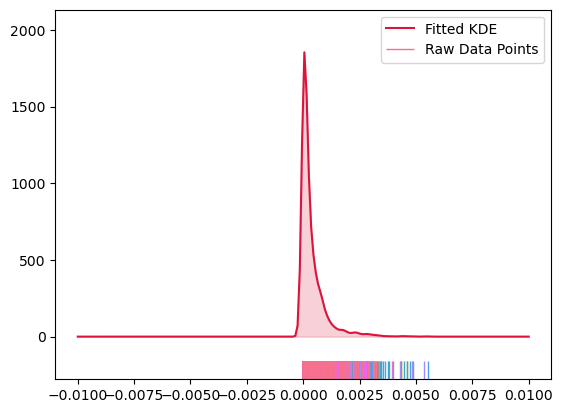

In [45]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fit your KDE
kde = kern_list[3]
data = kde.dataset

# 2. Map the line
x_grid = np.linspace(-0.01, 0.01, 200)
y_density = kde(x_grid)

# 3. Plot the extracted line
plt.plot(x_grid, y_density, color="crimson", label="Fitted KDE")
plt.fill_between(x_grid, y_density, alpha=0.2, color="crimson") # Fill under curve

# 4. Plot the source data as ticks at the bottom (Rug plot)
sns.rugplot(data, color="black", height=0.05, label="Raw Data Points")

plt.legend()
plt.show()


Okay, let's take a look at the coordinates of each voxel along with its variance. We'll do, x, y (grid) and the variance can be color.

In [27]:
print(kern_list[0])